In [ ]:
import pandas as pd

# Path to data frame with WSIs
df_path = "D:\DATA\with_snomed_category.csv"
df_all = pd.read_csv(df_path)
print(df_all.columns)

# Path to cache file
cache_file = "cache_all_slides.pkl"

# Path to zarr
zarr_dir = r"D:\NOTEBOOKS\Christine\all_slides\zarr"

In [ ]:
from helper_functions import strings2lists

list_str_cols = ['snomed_code', 'M', 'T', 'snomed_text', 'T_text', 'M_text', 'undersoeger_anonymous', 'T_category', 'M_category']

for col in list_str_cols: 
    df_all[col] = df_all[col].apply(strings2lists)

In [ ]:
from helper_functions import subset_df, subset_df_list

df_HE = subset_df(df_all, "stain", "HE")
df_HE = subset_df(df_HE, "mattype tekst", "Hist. store")
df_HE["T_category"].value_counts().head()

In [ ]:
df_HE = subset_df_list(df_HE, "T_text", "Placenta")

In [ ]:
# Feature Results
feature_result = r"D:\NOTEBOOKS\Christine\all_slides\feature_summary_old.csv"
df_feature_result = pd.read_csv(feature_result)
df_feature_result = df_feature_result[df_feature_result['status'] == "feature extraction complete"].copy()
df_features = df_feature_result[df_feature_result['model'] == "h-optimus-0"].copy()
with_features = set(df_features["wsi_path"])
print(len(with_features))

df_HE = df_HE[df_HE["filename"].isin(with_features)]
print(len(df_HE))

In [ ]:
# Subset with 2 samples per rekvnr
sub_rekvnr = df_HE["rekvnr"].value_counts()
sub_rekvnr = sub_rekvnr[sub_rekvnr >= 2].sample(n=5, random_state=42).index

df_HE = (
    df_HE[df_HE["rekvnr"].isin(sub_rekvnr)]
    .groupby("rekvnr", group_keys=False)
    .sample(n=2, random_state=42)
)
print(df_HE)

In [ ]:
all_filenames = df_HE["filename"].tolist()
print("Number of wsi filenames: ", len(all_filenames))

In [ ]:
# Save to csv
output_file = "D:\DATA\spatial_domain_exp1_placenta.csv"

df_HE.to_csv(output_file, index=False)
print(f"Saved DataFrame to {output_file}")

In [11]:
import pandas as pd

# Path to data frame with WSIs
df_path = "D:\DATA\spatial_domain_exp1_placenta.csv"
df_all = pd.read_csv(df_path)
print(df_all.columns)

# Path to cache file
cache_file = "cache_all_slides.pkl"

# Path to zarr
zarr_dir = r"D:\NOTEBOOKS\Christine\all_slides\zarr"

Index(['filename', 'rekvnr', 'modtdato', 'rekvprio', 'team', 'sex', 'alder',
       'alder gruppe', 'rekvdato', 'matantal', 'mattype tekst', 'glasalm',
       'immunalm', 'ishutaelalm', 'antglas', 'specfarv', 'stain',
       'snomed_code', 'M', 'T', 'snomed_text', 'T_text', 'M_text',
       'undersoeger_anonymous', 'T_category', 'M_category'],
      dtype='object')


In [12]:
print(df_all.head(4))

                                            filename    rekvnr    modtdato  \
0  //regsj.intern/appl/Deep_Visual_Proteomics\Sli...  12203711  2012-03-15   
1  //regsj.intern/appl/Deep_Visual_Proteomics\Sli...  12203711  2012-03-15   
2  //regsj.intern/appl/Deep_Visual_Proteomics\Sli...  12205380  2012-04-24   
3  //regsj.intern/appl/Deep_Visual_Proteomics\Sli...  12205380  2012-04-24   

  rekvprio team sex  alder alder gruppe    rekvdato  matantal  ... stain  \
0       NO  GYN   F     36        35-39  2012-03-09         1  ...    HE   
1       NO  GYN   F     36        35-39  2012-03-09         1  ...    HE   
2       NO  GYN   F     24        20-24  2012-04-24         1  ...    HE   
3       NO  GYN   F     24        20-24  2012-04-24         1  ...    HE   

                                snomed_code                     M  \
0  ['MÆ0025', 'T88800', 'T88100', 'M29650']  ['MÆ0025', 'M29650']   
1  ['MÆ0025', 'T88800', 'T88100', 'M29650']  ['MÆ0025', 'M29650']   
2                    

In [13]:
from helper_functions import strings2lists

list_str_cols = ['snomed_code', 'M', 'T', 'snomed_text', 'T_text', 'M_text', 'undersoeger_anonymous', 'T_category', 'M_category']

for col in list_str_cols: 
    df_all[col] = df_all[col].apply(strings2lists)

In [14]:
# Check unique counts and normalized categorical distributions to identify class imbalance
for col in df_all.columns:
    print(df_all[col].value_counts())
    print("")
    print(df_all[col].value_counts(normalize=True))
    print("-"*40)

filename
//regsj.intern/appl/Deep_Visual_Proteomics\Slides 02.04.2024\12203711011001.mrxs    1
//regsj.intern/appl/Deep_Visual_Proteomics\Slides 02.04.2024\12203711010201.mrxs    1
//regsj.intern/appl/Deep_Visual_Proteomics\Slides 02.05.2024\12205380011101.mrxs    1
//regsj.intern/appl/Deep_Visual_Proteomics\Slides 02.05.2024\12205380011001.mrxs    1
//regsj.intern/appl/Deep_Visual_Proteomics\Slides\12214921010503.mrxs               1
//regsj.intern/appl/Deep_Visual_Proteomics\Slides\12214921010601.mrxs               1
//regsj.intern/appl/Deep_Visual_Proteomics\Slides 06.03.2025\13205231010301.mrxs    1
//regsj.intern/appl/Deep_Visual_Proteomics\Slides 06.03.2025\13205231010501.mrxs    1
//regsj.intern/appl/Deep_Visual_Proteomics\Slides 01.04.2025\13206353010301.mrxs    1
//regsj.intern/appl/Deep_Visual_Proteomics\Slides 01.04.2025\13206353010201.mrxs    1
Name: count, dtype: int64

filename
//regsj.intern/appl/Deep_Visual_Proteomics\Slides 02.04.2024\12203711011001.mrxs    0.1
//regsj

In [15]:
all_filenames = df_all["filename"].tolist()
print("Number of wsi filenames: ", len(all_filenames))

Number of wsi filenames:  10


In [22]:
# UMAP of tile-level features
import os
from wsidata import open_wsi
import scanpy as sc
import pandas as pd

adatas = []

for i, path in enumerate(all_filenames):
    zarr_path = os.path.join(zarr_dir, os.path.basename(path).replace(".mrxs", ".zarr"))

    wsi = open_wsi(path, zarr_path)
    adata = wsi.tables["features_conch"]

    match = df_all.loc[df_all["filename"] == path, "rekvnr"]

    if not match.empty:
        rekvnr = str(match.iloc[0])
    else:
        rekvnr = f"unknown_{i}"

    adata.obs["rekvnr"] = [rekvnr] * adata.n_obs
    adatas.append(adata)

adata_concat = sc.concat(
    adatas,
    label="slide_id",
    keys=[f"slide_{i}" for i in range(len(adatas))]
)

adata_concat.obs["rekvnr"] = pd.Categorical(adata_concat.obs["rekvnr"])

version mismatch: detected: RasterFormatV02, requested: FormatV04
C:\ProgramData\miniconda3\envs\lazyslide_010_py310_uv_2\lib\site-packages\zarr\creation.py:614: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
version mismatch: detected: RasterFormatV02, requested: FormatV04
C:\ProgramData\miniconda3\envs\lazyslide_010_py310_uv_2\lib\site-packages\zarr\creation.py:614: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
version mismatch: detected: RasterFormatV02, requested: FormatV04
C:\ProgramData\miniconda3\envs\lazyslide_010_py310_uv_2\lib\site-packages\zarr\creation.py:614: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
version mismatch: detected: RasterFormatV02, requested: FormatV04
C:\ProgramData\miniconda3\envs\lazyslide_010_py310_uv_2\lib\site-packages

In [23]:
sc.pp.scale(adata_concat)
sc.pp.pca(adata_concat)
sc.pp.neighbors(adata_concat)
sc.tl.umap(adata_concat)

C:\ProgramData\miniconda3\envs\lazyslide_010_py310_uv_2\lib\site-packages\sklearn\manifold\_spectral_embedding.py:328: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


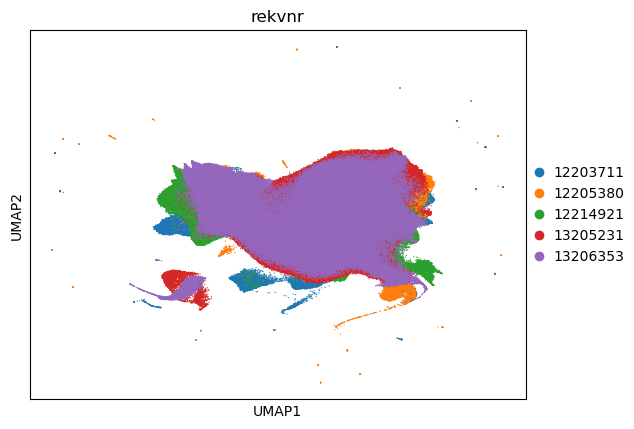

In [24]:
sc.pl.umap(adata_concat, color='rekvnr', size=3)

In [16]:
# Compute Spatial Domains Using LazySlide

import lazyslide as zs
import os
from wsidata import open_wsi

models = ['conch', 'h-optimus-0', 'uni']

compute_domains = True

if compute_domains:
    for file in all_filenames:
        zarr_path = os.path.join(zarr_dir, os.path.basename(file).replace(".mrxs", ".zarr"))
        wsi = open_wsi(file, zarr_path)
        
        for model in models:
            feature_key = f'features_{model}'
            domain_key = f'domain_{model}'

            if domain_key in wsi.shapes["tiles_224"]:
                print(f"Key: {domain_key} already exist for slide: {file}")
                continue

            zs.tl.spatial_domain(
                wsi,
                feature_key=feature_key,  
                tile_key="tiles_224",                
                resolution=0.2,                    
                key_added=domain_key                  
            )
            wsi.write(zarr_path)
        
            print(f"Model: {model}, Key added for slide: {file}")

version mismatch: detected: RasterFormatV02, requested: FormatV04
C:\ProgramData\miniconda3\envs\lazyslide_010_py310_uv_2\lib\site-packages\zarr\creation.py:614: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)


Model: conch, Key added for slide: //regsj.intern/appl/Deep_Visual_Proteomics\Slides 02.04.2024\12203711011001.mrxs
Model: h-optimus-0, Key added for slide: //regsj.intern/appl/Deep_Visual_Proteomics\Slides 02.04.2024\12203711011001.mrxs
Model: uni, Key added for slide: //regsj.intern/appl/Deep_Visual_Proteomics\Slides 02.04.2024\12203711011001.mrxs


version mismatch: detected: RasterFormatV02, requested: FormatV04
C:\ProgramData\miniconda3\envs\lazyslide_010_py310_uv_2\lib\site-packages\zarr\creation.py:614: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)


Model: conch, Key added for slide: //regsj.intern/appl/Deep_Visual_Proteomics\Slides 02.04.2024\12203711010201.mrxs
Model: h-optimus-0, Key added for slide: //regsj.intern/appl/Deep_Visual_Proteomics\Slides 02.04.2024\12203711010201.mrxs
Model: uni, Key added for slide: //regsj.intern/appl/Deep_Visual_Proteomics\Slides 02.04.2024\12203711010201.mrxs


version mismatch: detected: RasterFormatV02, requested: FormatV04
C:\ProgramData\miniconda3\envs\lazyslide_010_py310_uv_2\lib\site-packages\zarr\creation.py:614: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)


...

Model: conch, Key added for slide: //regsj.intern/appl/Deep_Visual_Proteomics\Slides 06.03.2025\13205231010501.mrxs
Model: h-optimus-0, Key added for slide: //regsj.intern/appl/Deep_Visual_Proteomics\Slides 06.03.2025\13205231010501.mrxs
Model: uni, Key added for slide: //regsj.intern/appl/Deep_Visual_Proteomics\Slides 06.03.2025\13205231010501.mrxs


version mismatch: detected: RasterFormatV02, requested: FormatV04
C:\ProgramData\miniconda3\envs\lazyslide_010_py310_uv_2\lib\site-packages\zarr\creation.py:614: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)


Model: conch, Key added for slide: //regsj.intern/appl/Deep_Visual_Proteomics\Slides 01.04.2025\13206353010301.mrxs
Model: h-optimus-0, Key added for slide: //regsj.intern/appl/Deep_Visual_Proteomics\Slides 01.04.2025\13206353010301.mrxs
Model: uni, Key added for slide: //regsj.intern/appl/Deep_Visual_Proteomics\Slides 01.04.2025\13206353010301.mrxs


version mismatch: detected: RasterFormatV02, requested: FormatV04
C:\ProgramData\miniconda3\envs\lazyslide_010_py310_uv_2\lib\site-packages\zarr\creation.py:614: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)


Model: conch, Key added for slide: //regsj.intern/appl/Deep_Visual_Proteomics\Slides 01.04.2025\13206353010201.mrxs
Model: h-optimus-0, Key added for slide: //regsj.intern/appl/Deep_Visual_Proteomics\Slides 01.04.2025\13206353010201.mrxs
Model: uni, Key added for slide: //regsj.intern/appl/Deep_Visual_Proteomics\Slides 01.04.2025\13206353010201.mrxs


In [17]:
from spatial_agreement import SpatialAgreement
agreement = SpatialAgreement(all_filenames, zarr_dir, models)

version mismatch: detected: RasterFormatV02, requested: FormatV04
C:\ProgramData\miniconda3\envs\lazyslide_010_py310_uv_2\lib\site-packages\zarr\creation.py:614: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
version mismatch: detected: RasterFormatV02, requested: FormatV04
C:\ProgramData\miniconda3\envs\lazyslide_010_py310_uv_2\lib\site-packages\zarr\creation.py:614: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
version mismatch: detected: RasterFormatV02, requested: FormatV04
C:\ProgramData\miniconda3\envs\lazyslide_010_py310_uv_2\lib\site-packages\zarr\creation.py:614: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
version mismatch: detected: RasterFormatV02, requested: FormatV04
C:\ProgramData\miniconda3\envs\lazyslide_010_py310_uv_2\lib\site-packages

In [18]:
print(agreement.overall_slide_agreement())

    slide_idx            comparison  agreement_rate
0           0  conch_vs_h-optimus-0        0.700281
1           0          conch_vs_uni        0.603675
2           0    h-optimus-0_vs_uni        0.558781
3           0             all_agree        0.453816
4           1  conch_vs_h-optimus-0        0.904412
5           1          conch_vs_uni        0.896330
6           1    h-optimus-0_vs_uni        0.961131
7           1             all_agree        0.882793
8           2  conch_vs_h-optimus-0        0.739403
9           2          conch_vs_uni        0.796185
10          2    h-optimus-0_vs_uni        0.648461
11          2             all_agree        0.595386
12          3  conch_vs_h-optimus-0        0.897985
13          3          conch_vs_uni        0.914149
14          3    h-optimus-0_vs_uni        0.898319
15          3             all_agree        0.856647
16          4  conch_vs_h-optimus-0        0.801477
17          4          conch_vs_uni        0.777734
18          

In [19]:
agreement.summary_slide_agreement()

,count,mean,std,min,25%,50%,75%,max
comparison,,,,,,,,
all_agree,10.0,0.663453,0.161809,0.448176,0.559791,0.639381,0.817418,0.882793
conch_vs_h-optimus-0,10.0,0.766465,0.107370,0.606011,0.700584,0.764653,0.864414,0.904412
conch_vs_uni,10.0,0.774661,0.125670,0.518398,0.767137,0.788673,0.862125,0.914149
h-optimus-0_vs_uni,10.0,0.770305,0.135909,0.558781,0.670917,0.753776,0.888003,0.961131


In [20]:
i = 0
print(agreement.slide_level_agreement(i))

{'conch_vs_h-optimus-0': 0.7002813178892148, 'conch_vs_uni': 0.6036754866332289, 'h-optimus-0_vs_uni': 0.558781423007999, 'full_agreement': 0.4538161455778363}


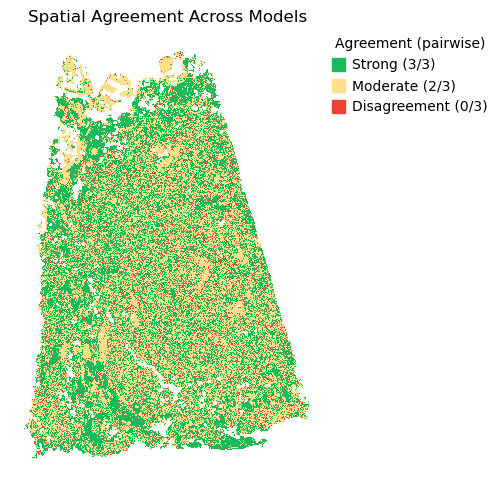

In [21]:
agreement.plot_agreement_map(i)

In [ ]:
# agreement.boxplot_slide_agreement()

In [ ]:
# agreement.stripplot_slide_agreement()

In [ ]:
# UPDATE
from spatial_domain_tile_selection import TileSelector

selector_multi = TileSelector(
        wsi=wsi,
        feature_key="features_conch", 
        domain_keys=["domain_conch", "domain_uni_aligned", "domain_hopt_aligned"],
        tile_key = "tiles_224",
        n_per_domain=4,
        agreement_mode="all_same",
)

selected_tiles_multi = selector_multi.select_tiles_per_domain()
print(f"Selected {len(selected_tiles_multi)} tiles with consensus")
print(selected_tiles_multi.head())

In [ ]:
# UPDATE
selector_multi.plot_domains(selected_tiles_multi)